In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

## randseed = 1

In [2]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [3]:
famtree_bigstep_1 = pd.read_csv(
    "famtree_bigstep_1",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [4]:
heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

# Read the files
heartbeat_bigstep_1 = pd.read_csv(
    "heartbeat_bigstep_1", 
    names=heartbeat_column_names, 
    header=None
)

In [5]:
# 1. Get initial values (from the first row)
initial_mass = heartbeat_bigstep_1["total_mass"].iloc[0]
initial_energy = heartbeat_bigstep_1["energy"].iloc[0]

L_x0 = heartbeat_bigstep_1["ang_mom_x"].iloc[0]
L_y0 = heartbeat_bigstep_1["ang_mom_y"].iloc[0]
L_z0 = heartbeat_bigstep_1["ang_mom_z"].iloc[0]
initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)

# 2. Calculate current angular momentum magnitude for all rows
current_L_mag = np.sqrt(
    heartbeat_bigstep_1["ang_mom_x"]**2 + 
    heartbeat_bigstep_1["ang_mom_y"]**2 + 
    heartbeat_bigstep_1["ang_mom_z"]**2
)

# 3. Add the relative error columns
heartbeat_bigstep_1["mass_error"] = abs((heartbeat_bigstep_1["total_mass"] - initial_mass) / initial_mass)
heartbeat_bigstep_1["energy_error"] = abs((heartbeat_bigstep_1["energy"] - initial_energy) / initial_energy)
heartbeat_bigstep_1["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)

In [6]:
famtree_less_than_min_mass = famtree_bigstep_1[famtree_bigstep_1['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
44,24278.95,8,90,65,66,2.880145e-10,4.552382e-08,3.389238e-08,2.387874e-06,0.000013,0.000012,9.775340,0.799003
50,24284.32,8,97,95,94,1.620771e-09,1.584543e-08,1.579184e-08,4.247309e-06,0.000009,0.000009,2.134492,0.710767
60,25336.90,8,112,101,109,2.541226e-11,1.582713e-08,1.400000e-08,1.063052e-06,0.000009,0.000009,8.525109,0.686195
66,27005.83,8,121,64,118,2.012674e-10,9.702898e-08,1.400000e-08,2.119001e-06,0.000017,0.000009,25.084320,0.774575
78,27019.35,8,136,133,124,1.282372e-09,1.763187e-08,1.587186e-08,3.928361e-06,0.000009,0.000009,4.881471,1.031827
84,27031.57,8,145,142,138,2.896278e-11,1.634939e-08,1.607323e-08,1.110419e-06,0.000009,0.000009,8.100416,0.639161
91,27969.91,8,156,127,97,1.955126e-10,1.580453e-08,1.620771e-09,2.098609e-06,0.000009,0.000004,27.765830,1.063267
93,28858.89,8,159,157,134,9.189930e-10,1.722979e-08,1.584035e-08,3.515422e-06,0.000009,0.000009,3.995141,0.883790
98,30428.75,8,166,164,119,6.294762e-13,1.842262e-08,1.587261e-08,3.098844e-07,0.000010,0.000009,28.917690,0.655577
113,35630.57,8,189,185,184,3.062786e-10,1.730353e-08,1.400000e-08,2.437318e-06,0.000009,0.000009,9.637413,1.026281


In [7]:
coll_newid_90 = famtree_less_than_min_mass[famtree_less_than_min_mass['new_id'] == 90]
coll_newid_90

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
44,24278.95,8,90,65,66,2.880145e-10,4.552382e-08,3.389238e-08,0.000002,0.000013,0.000012,9.77534,0.799003


In [8]:
famtree_with_sun = famtree_bigstep_1[(np.isclose(famtree_bigstep_1['parent1_mass'], 1)) | (np.isclose(famtree_bigstep_1['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
43,24276.65,3,88,0,85,1.0,1.000000e+00,4.213810e-08,0.00465,0.004650,0.000013,132.4599,0.105358
90,27177.74,1,154,88,151,1.0,1.000000e+00,1.400000e-08,0.00465,0.004650,0.000009,128.2154,1.069432
105,31511.61,1,177,90,154,1.0,2.880145e-10,1.000000e+00,0.00465,0.000002,0.004650,127.9794,1.566716
106,31545.96,1,179,172,177,1.0,3.429523e-08,1.000000e+00,0.00465,0.000012,0.004650,127.4390,1.569312


In [9]:
coll_newid_88 = famtree_with_sun[famtree_with_sun['new_id'] == 88]
coll_newid_88

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
43,24276.65,3,88,0,85,1.0,1.0,4.213810e-08,0.00465,0.00465,0.000013,132.4599,0.105358


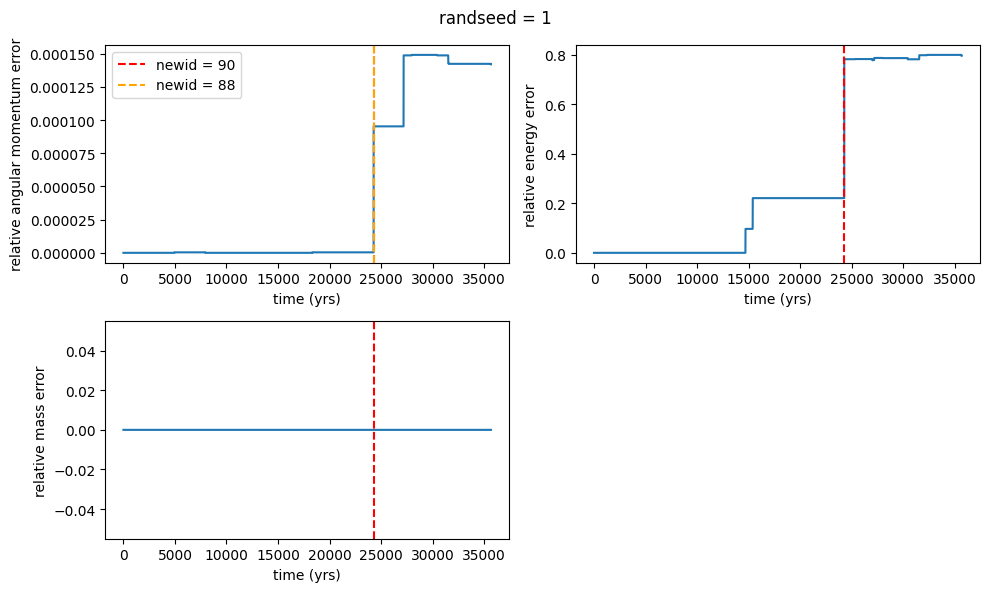

In [10]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['angular_momentum_error'])
plt.axvline(coll_newid_90['t'].iloc[0], color = 'red', linestyle = '--', label = 'newid = 90')
plt.axvline(coll_newid_88['t'].iloc[0], color = 'orange', linestyle = '--', label = 'newid = 88')
plt.legend()
plt.xlabel("time (yrs)")
plt.ylabel("relative angular momentum error")

plt.subplot(2,2,2)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['energy_error'])
plt.axvline(coll_newid_90['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative energy error")

plt.subplot(2,2,3)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['mass_error'])
plt.axvline(coll_newid_90['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative mass error")

plt.suptitle("randseed = 1")
plt.tight_layout()